# Task 3

## Model Validation, Overfitting Control & Hyperparameter Tuning

# 1. Aim

To implement model validation, overfitting detection, cross-validation, and hyperparameter tuning techniques using machine learning algorithms on the California Housing Dataset in order to improve model performance and generalization accuracy.

# 2. Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 3. Load and Prepare Dataset

In [2]:
# Load California Housing Dataset
data = fetch_california_housing(as_frame=True)

# Create dataframe
df = pd.concat(
    [data.data, data.target.rename("HousePrice")],
    axis=1
)

# Display first 5 rows
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  HousePrice  
0    -122.23       4.526  
1    -122.22       3.585  
2    -122.24       3.521  
3    -122.25       3.413  
4    -122.25       3.422  


# 4. Separate Features and Target

In [3]:
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

# 5. Feature Scaling

In [4]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# 6. Train-Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

# 7. Train Baseline Models
## Linear Regression

In [6]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression RMSE:", lr_rmse)
print("Linear Regression R2 Score:", lr_r2)

Linear Regression RMSE: 0.7455813830127762
Linear Regression R2 Score: 0.575787706032451


## Ridge Regression

In [7]:
ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression RMSE:", ridge_rmse)
print("Ridge Regression R2 Score:", ridge_r2)

Ridge Regression RMSE: 0.74555429093846
Ridge Regression R2 Score: 0.5758185345441331


# 8. Detect Overfitting Using Decision Tree

In [8]:
tree = DecisionTreeRegressor(random_state=42)

tree.fit(X_train, y_train)

train_pred = tree.predict(X_train)
test_pred = tree.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

print("Training RMSE:", train_rmse)
print("Testing RMSE:", test_rmse)

Training RMSE: 3.0302402915898627e-16
Testing RMSE: 0.7059501046231196


# 9. Cross Validation

In [9]:
cv_scores = cross_val_score(
    tree,
    X_scaled,
    y,
    scoring='neg_root_mean_squared_error',
    cv=5
)

cv_rmse = -cv_scores.mean()

print("Cross Validation RMSE:", cv_rmse)

Cross Validation RMSE: 0.9029281160721967


# 10. Hyperparameter Tuning Using GridSearchCV

In [10]:
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 10}


# 11. Evaluate Optimized Model

In [11]:
best_tree = grid.best_estimator_

y_pred = best_tree.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Optimized Model RMSE:", rmse)
print("Optimized Model R2 Score:", r2)

Optimized Model RMSE: 0.6454300828015771
Optimized Model R2 Score: 0.6820992539714815


# 12. Model Comparison Table

In [12]:
results = {
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Optimized Decision Tree"
    ],

    "RMSE": [
        lr_rmse,
        ridge_rmse,
        rmse
    ],

    "R2 Score": [
        lr_r2,
        ridge_r2,
        r2
    ]
}

results_df = pd.DataFrame(results)

print(results_df)

                     Model      RMSE  R2 Score
0        Linear Regression  0.745581  0.575788
1         Ridge Regression  0.745554  0.575819
2  Optimized Decision Tree  0.645430  0.682099


# 13. Visualization

## RMSE Comparison Plot

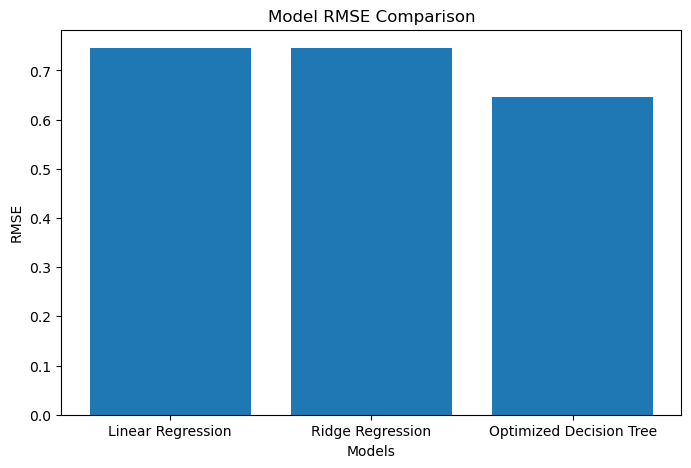

In [13]:
plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["RMSE"])

plt.title("Model RMSE Comparison")
plt.xlabel("Models")
plt.ylabel("RMSE")

plt.show()

## R² Score Comparison Plot

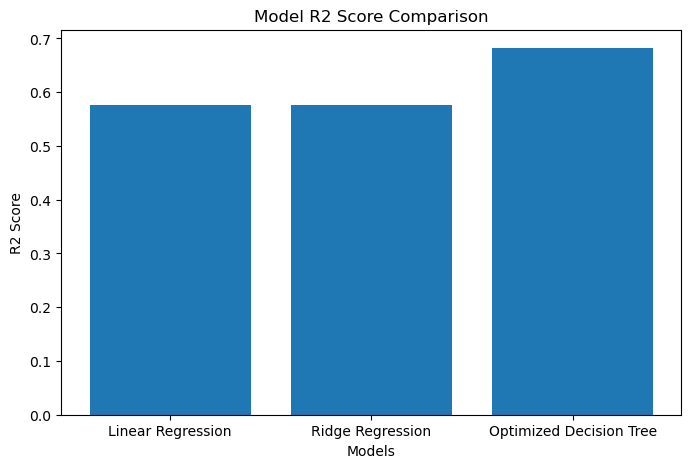

In [14]:
plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["R2 Score"])

plt.title("Model R2 Score Comparison")
plt.xlabel("Models")
plt.ylabel("R2 Score")

plt.show()